In [71]:
from pathlib import Path

folder = Path("../talk.politics.mideast")
nb = sum(1 for p in folder.iterdir() if p.is_file())
print("Nombre de fichiers :", nb)

Nombre de fichiers : 940


In [72]:
import os
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import Normalizer
from sklearn.metrics.pairwise import cosine_similarity

import nltk
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.corpus import stopwords
import string


In [73]:
# ---------------------------------------------------------
# 1. Préparation NLP (NLTK)
# ---------------------------------------------------------

nltk.download("wordnet")
nltk.download("stopwords")

EN_STOPWORDS = set(stopwords.words("english"))
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\MGI\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\MGI\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [74]:

# ---------------------------------------------------------
# 2. Fonction de prétraitement configurable
# ---------------------------------------------------------

def custom_preprocess(text,
                      lower=True,
                      remove_punct=True,
                      remove_stopwords=True,
                      stemming=False,
                      lemmatizing=False):
    # minuscule
    if lower:
        text = text.lower()

    # segmentation simple
    tokens = text.split()

    # ponctuation
    if remove_punct:
        tokens = ["".join([c for c in tok if c not in string.punctuation]) for tok in tokens]
        tokens = [tok for tok in tokens if tok.strip() != ""]

    # stopwords
    if remove_stopwords:
        tokens = [tok for tok in tokens if tok not in EN_STOPWORDS]

    # stemming
    if stemming:
        tokens = [stemmer.stem(tok) for tok in tokens]

    # lemmatisation
    if lemmatizing:
        tokens = [lemmatizer.lemmatize(tok) for tok in tokens]

    return " ".join(tokens)

In [75]:
# ---------------------------------------------------------
# 3. Chargement des documents (un dossier contenant .txt)
# ---------------------------------------------------------

from pathlib import Path

def load_documents(folder):
    folder = Path(folder)
    docs, filenames = [], []

    for p in folder.rglob("*"):
        if p.is_file():
            try:
                text = p.read_text(encoding="utf-8")
            except UnicodeDecodeError:
                text = p.read_text(encoding="latin-1", errors="ignore")

            if text and text.strip():
                docs.append(text)
                filenames.append(str(p.relative_to(folder)))

    return filenames, docs

In [76]:
# ---------------------------------------------------------
# 4. Construction TF-IDF avec options de prétraitement
# ---------------------------------------------------------

PREPROC_TEXT = dict(
    lower=True,
    remove_punct=True,
    remove_stopwords=True,
    stemming=False,
    lemmatizing=True,
)

TFIDF_PARAMS = dict(
    ngram=1,
    min_df=1,
    max_df=1.0
)

def compute_tfidf(docs, preproc_text, tfidf_params):
    processed_docs = [custom_preprocess(doc, **preproc_text) for doc in docs]

    vectorizer = TfidfVectorizer(
        stop_words=None,
        ngram_range=(1, tfidf_params.get("ngram", 1)),
        min_df=tfidf_params.get("min_df", 1),
        max_df=tfidf_params.get("max_df", 1.0)
    )

    X = vectorizer.fit_transform(processed_docs)
    terms = vectorizer.get_feature_names_out()

    return X, terms, processed_docs, vectorizer

In [77]:
# ---------------------------------------------------------
# 5. LSA (Truncated SVD)
# ---------------------------------------------------------

def compute_lsa(X, k=5):
    svd = TruncatedSVD(n_components=k, random_state=0)

    # V^T (concept -> termes) dans sklearn
    Vt = svd.fit(X).components_          # (k, n_terms)

    Sigma = svd.singular_values_         # (k,)
    U_terms = Vt.T                       # (n_terms, k)  (termes -> concepts)

    # V (documents -> concepts) = UΣ = svd.transform(X)
    V_docs = svd.transform(X)            # (n_docs, k)

    # optionnel: version normalisée (souvent utilisée pour cosine similarity)
    normalizer = Normalizer(copy=False)
    X_lsa = normalizer.fit_transform(V_docs.copy())

    return U_terms, Sigma, V_docs, X_lsa, svd, normalizer


In [78]:
# ---------------------------------------------------------
# 6. Heatmaps
# ---------------------------------------------------------

def plot_heatmap(matrix, title, xlabels=None, ylabels=None, figsize=(10, 6)):
    plt.figure(figsize=figsize)

    kwargs = {"cmap": "viridis"}
    if xlabels is not None:
        kwargs["xticklabels"] = xlabels
    if ylabels is not None:
        kwargs["yticklabels"] = ylabels

    sns.heatmap(matrix, **kwargs)

    plt.title(title)
    plt.tight_layout()
    plt.show()

In [79]:
# ---------------------------------------------------------
# 7. Comparaison TF-IDF vs LSA pour une requête
# ---------------------------------------------------------
def compare_query(query, vectorizer, X, svd, normalizer, V, preproc_text):
    q = custom_preprocess(query, **preproc_text)

    # TF-IDF
    q_vec = vectorizer.transform([q])
    sim_tfidf = cosine_similarity(q_vec, X)[0]

    # LSA : projeter la requête dans le même espace que V
    q_lsa = svd.transform(q_vec)
    q_lsa = normalizer.transform(q_lsa)

    # V doit être normalisé pareil (au cas où)
    Vn = normalizer.transform(np.asarray(V).copy())

    sim_lsa = cosine_similarity(q_lsa, Vn)[0]

    return sim_tfidf, sim_lsa


Nb documents : 919
TF-IDF shape : (919, 18066)


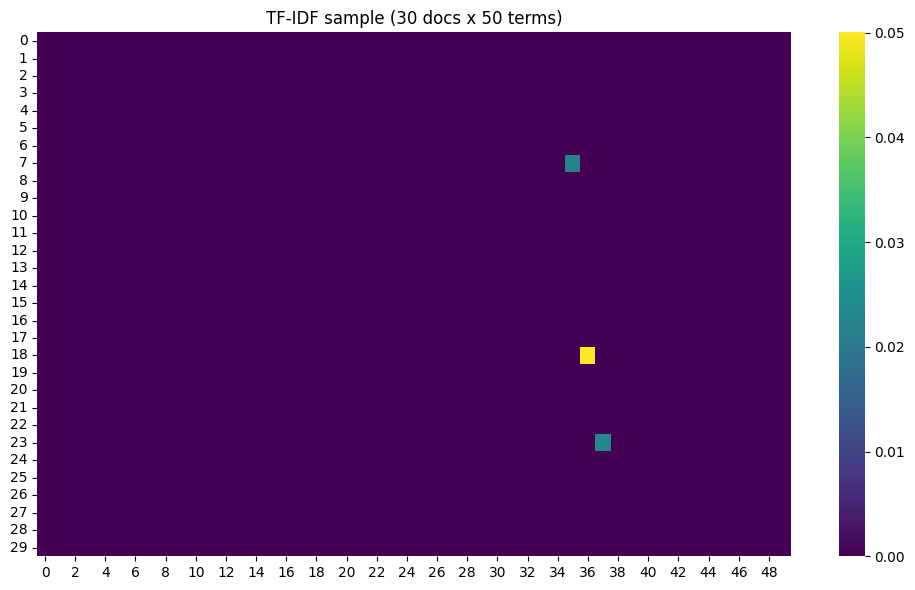

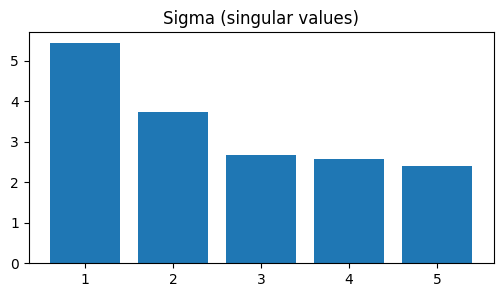

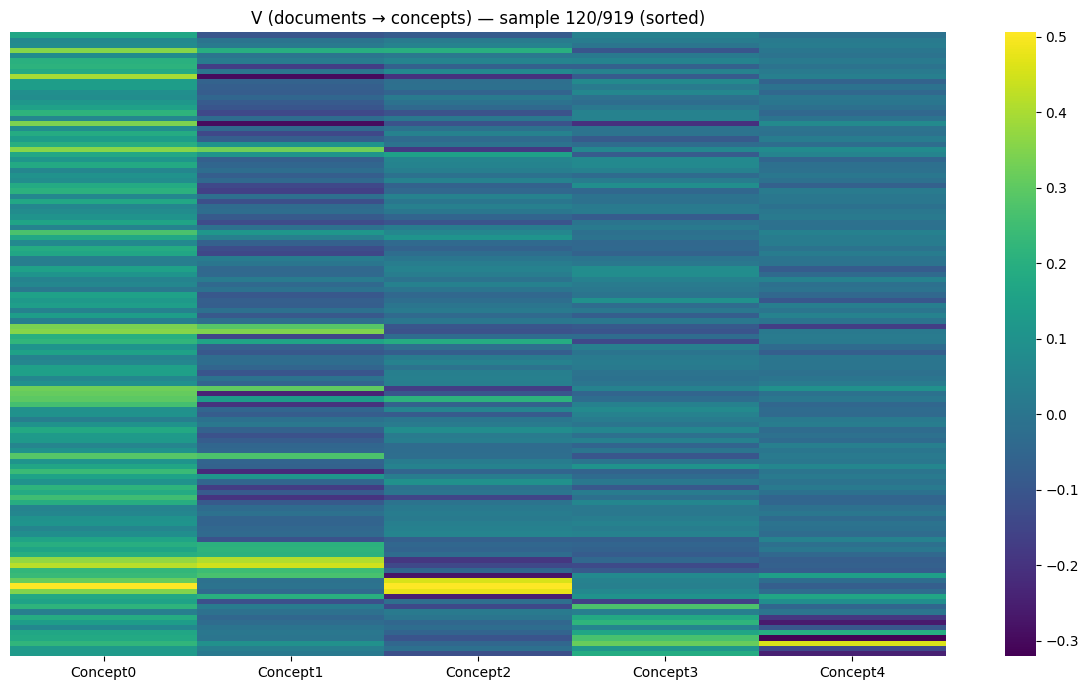

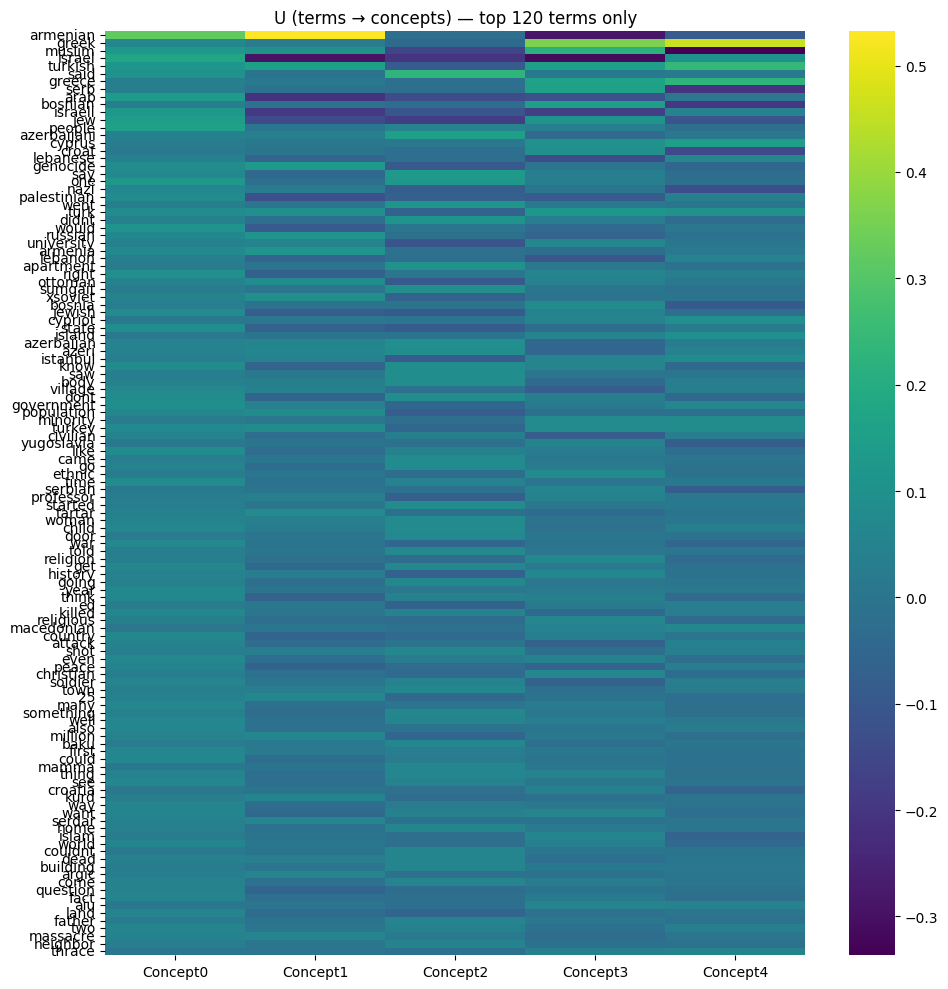

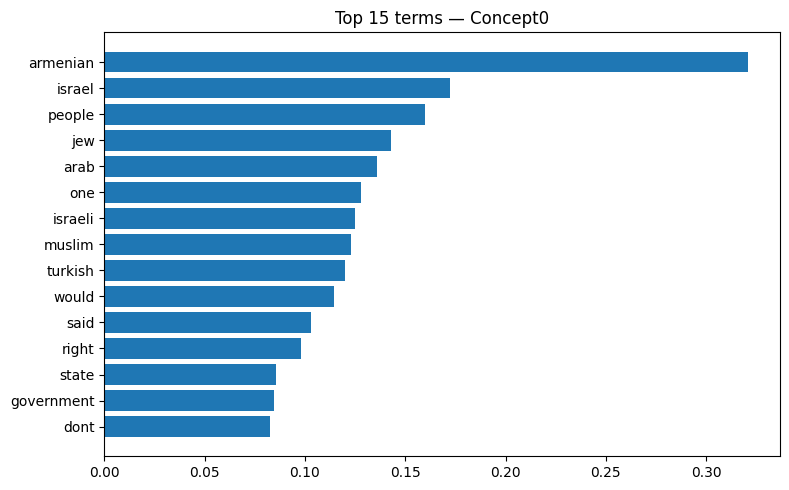

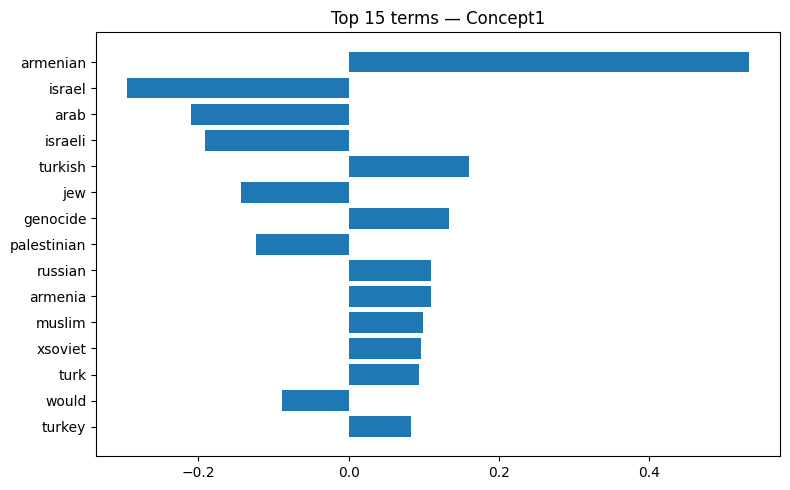

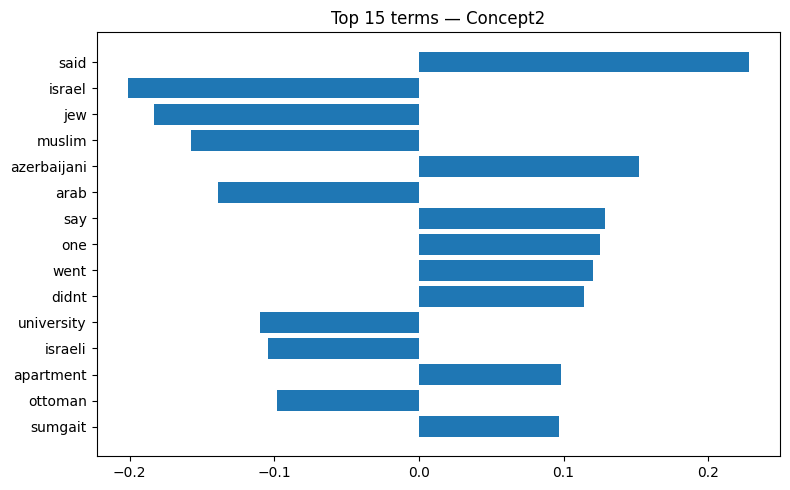

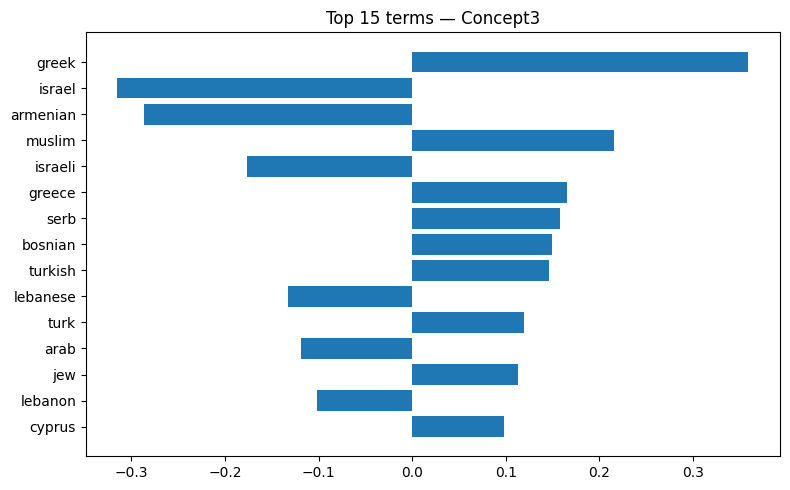

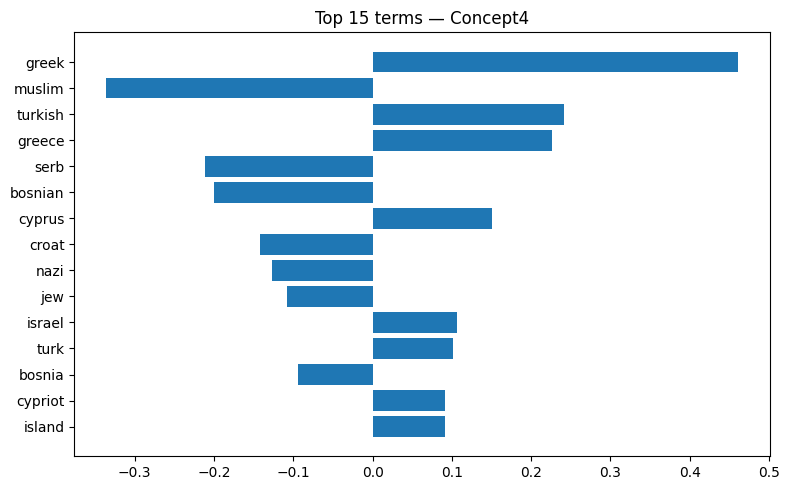


Requête : israel palestinian conflict

TF-IDF ranking (top 10):
[('doc_14367.txt', np.float64(0.33164102261468265)), ('doc_02449.txt', np.float64(0.30149880069115653)), ('doc_01054.txt', np.float64(0.2862292462330023)), ('doc_07797.txt', np.float64(0.2834006904871687)), ('doc_18448.txt', np.float64(0.26104773988020774)), ('doc_04859.txt', np.float64(0.24500951559630685)), ('doc_01239.txt', np.float64(0.23998312627542237)), ('doc_04108.txt', np.float64(0.21231659830499994)), ('doc_05961.txt', np.float64(0.2120416478794427)), ('doc_09990.txt', np.float64(0.20783427423157783))]

LSA ranking (top 10):
[('doc_15143.txt', np.float64(0.9940699876412095)), ('doc_15263.txt', np.float64(0.9928454833373792)), ('doc_17539.txt', np.float64(0.9920250572923571)), ('doc_07843.txt', np.float64(0.9887776215866958)), ('doc_05267.txt', np.float64(0.9887426644359842)), ('doc_15852.txt', np.float64(0.9864862844055245)), ('doc_05961.txt', np.float64(0.985871281115668)), ('doc_15077.txt', np.float64(0.984400

In [80]:
# ---------------------------------------------------------
# 8. EXEMPLE COMPLET D’UTILISATION
# ---------------------------------------------------------
    # --- Paramètres utilisateur ---
FOLDER = "../talk.politics.mideast"

PREPROC_TEXT = dict(
    lower=True,
    remove_punct=True,
    remove_stopwords=True,
    stemming=False,
    lemmatizing=True,
)

TFIDF_PARAMS = dict(
    ngram=1,
    min_df=1,
    max_df=1.0
)

K = 5

    # --- Chargement ---
filenames, docs = load_documents(FOLDER)
print("Nb documents :", len(docs))

    # --- TF-IDF ---
X, terms, processed_docs, vectorizer = compute_tfidf(
    docs,
    PREPROC_TEXT,
    TFIDF_PARAMS
)

print("TF-IDF shape :", X.shape)

    # --- Heatmap TF-IDF ---
plot_heatmap(
    X[:30, :50].toarray(),
    title="TF-IDF sample (30 docs x 50 terms)"
)

    # --- LSA ---
U, Sigma, V, X_lsa, svd, normalizer = compute_lsa(X, k=K)

    # Σ
plt.figure(figsize=(6,3))
plt.bar(range(1, len(Sigma)+1), Sigma)
plt.title("Sigma (singular values)")
plt.show()

# -------------------------
# U et V lisibles
# -------------------------

# V (docs -> concepts) : échantillon + tri
V_arr = np.asarray(V)
n_docs = V_arr.shape[0]
dominant = np.argmax(np.abs(V_arr), axis=1)
order = np.argsort(dominant)

max_docs = 120
if n_docs > max_docs:
    idx = order[np.linspace(0, n_docs - 1, max_docs, dtype=int)]
else:
    idx = order

V_sub = V_arr[idx, :]

plt.figure(figsize=(12, 7))
sns.heatmap(V_sub, cmap="viridis", yticklabels=False,
            xticklabels=[f"Concept{i}" for i in range(K)])
plt.title(f"V (documents → concepts) — sample {len(idx)}/{n_docs} (sorted)")
plt.tight_layout()
plt.show()

# U (terms -> concepts) : on garde seulement les termes les plus importants
U_arr = np.asarray(U)
score = np.max(np.abs(U_arr), axis=1)

top_terms_global = 120
top_idx = np.argsort(score)[-top_terms_global:][::-1]

U_sub = U_arr[top_idx, :]
terms_sub = [terms[i] for i in top_idx]

plt.figure(figsize=(10, 10))
sns.heatmap(U_sub, cmap="viridis",
            xticklabels=[f"Concept{i}" for i in range(K)],
            yticklabels=terms_sub)
plt.title(f"U (terms → concepts) — top {top_terms_global} terms only")
plt.tight_layout()
plt.show()

# Bonus: top mots par concept 
top_n = 15
for c in range(K):
    weights = U_arr[:, c]
    idx_c = np.argsort(np.abs(weights))[-top_n:][::-1]

    words = [terms[i] for i in idx_c][::-1]
    vals = weights[idx_c][::-1]

    plt.figure(figsize=(8, 5))
    plt.barh(words, vals)
    plt.title(f"Top {top_n} terms — Concept{c}")
    plt.tight_layout()
    plt.show()

# --- Comparaison sur plusieurs requêtes ---

queries = [
    "israel palestinian conflict",
    "middle east peace process",
    "religious tension jerusalem"
]

for query in queries:

    sim_tfidf, sim_lsa = compare_query(
        query,
        vectorizer,
        X,
        svd,
        normalizer,
        V,
        PREPROC_TEXT
    )

    print("\n" + "="*60)
    print("Requête :", query)

    print("\nTF-IDF ranking (top 10):")
    print(sorted(zip(filenames, sim_tfidf), key=lambda x: -x[1])[:10])

    print("\nLSA ranking (top 10):")
    print(sorted(zip(filenames, sim_lsa), key=lambda x: -x[1])[:10])
    print("Max TF-IDF:", max(sim_tfidf))
    print("Max LSA:", max(sim_lsa))